In [1]:
import torchvision
import torch
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import Dataset
flowers_data = torchvision.datasets.Flowers102('.', download=True)
import torchvision.transforms as T

  0%|          | 164k/345M [00:12<7:12:27, 13.3kB/s] 


KeyboardInterrupt: 

In [ ]:
class LectorAumentado(Dataset):
  def __init__(self):
    self.X = [] #imagenes
    self.Y = [] #Etiquetas
  #El método __len__ permite conocer el tamaño de los datos.
  def __len__(self):
      return len(self.X)
  def __getitem__(self, i):
      return self.X[i], self.Y[i]
  def add(self, im, lbl):
    #Proceso de aumentar la imagen
    self.X.append(im) #La imagen original
    self.Y.append(lbl)

    self.X.append(T.Grayscale()(im)) #La imagen en blanco y negro
    self.Y.append(lbl)
    self.X.append(T.functional.rotate(im, np.random.randint(360))) #Una rotación
    self.Y.append(lbl)
    self.X.append(T.functional.hflip(im)) #Una rotación
    self.Y.append(lbl)
    self.X.append(T.functional.vflip(im)) #Una rotación
    self.Y.append(lbl)



In [ ]:
from tqdm import tqdm
lector=LectorAumentado()
for im, lbl in tqdm(flowers_data):
  lector.add(im, lbl)

100%|██████████| 1020/1020 [00:11<00:00, 86.95it/s] 


Text(0.5, 1.0, '0')

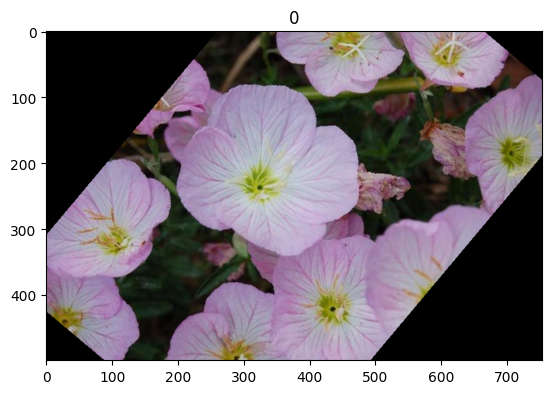

In [ ]:
len(lector)
plt.imshow(lector[2][0])
plt.title(lector[2][1])


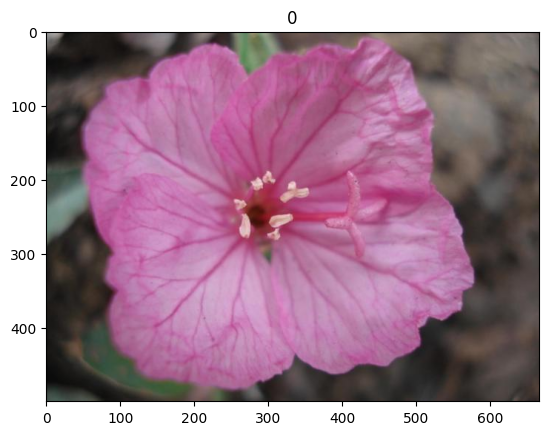

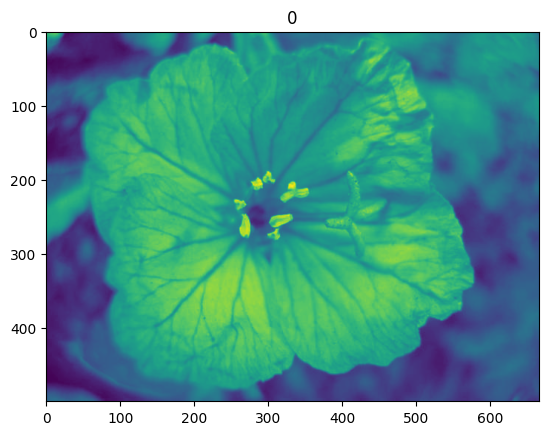

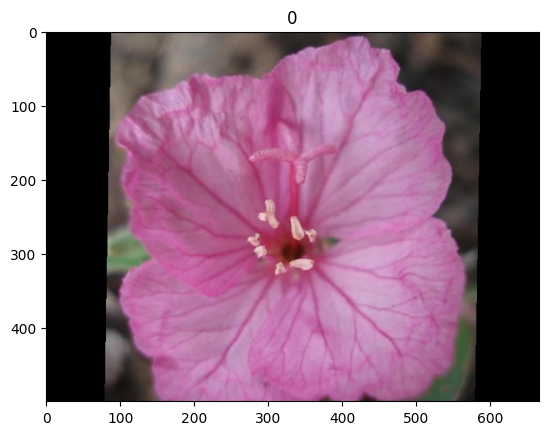

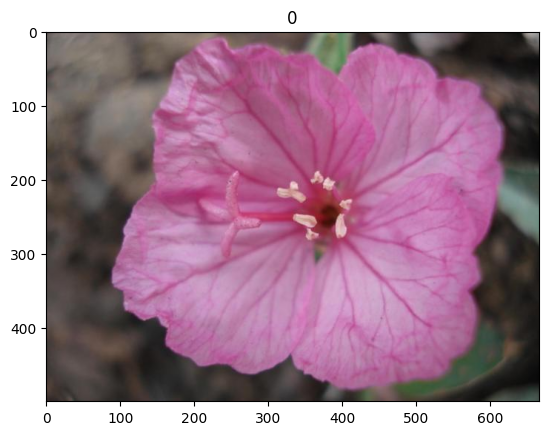

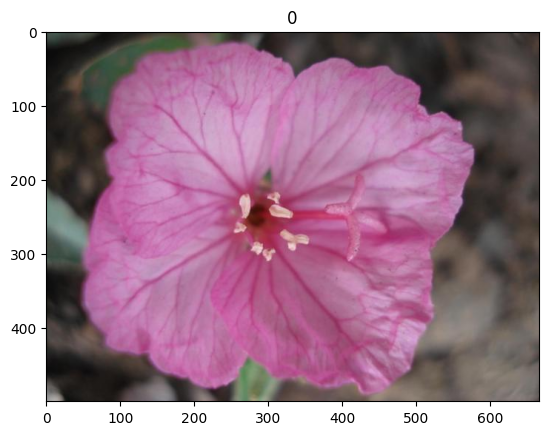

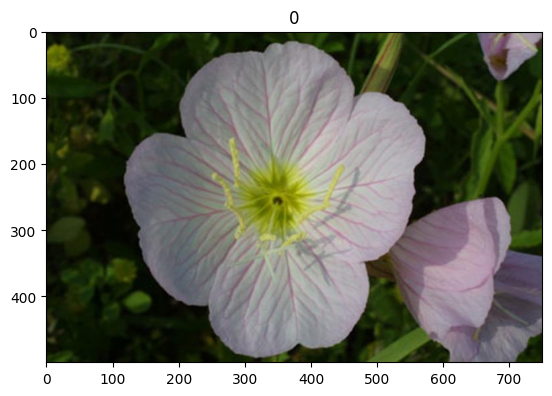

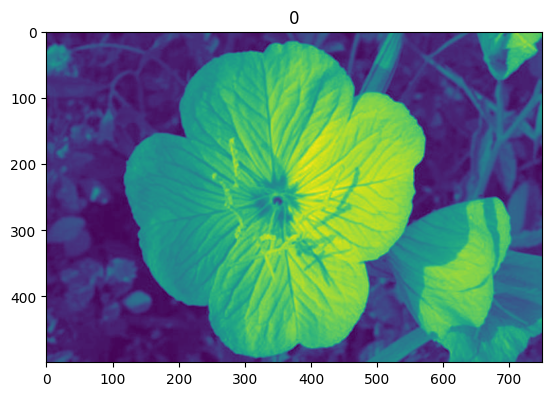

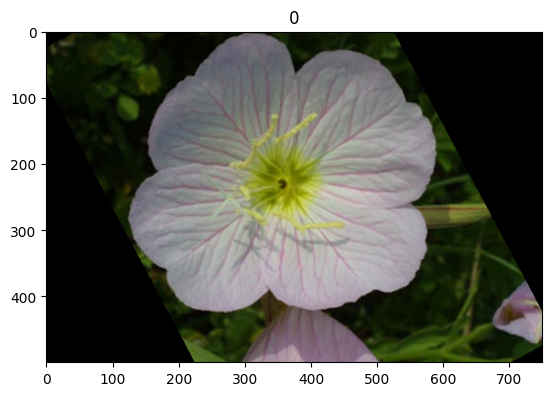

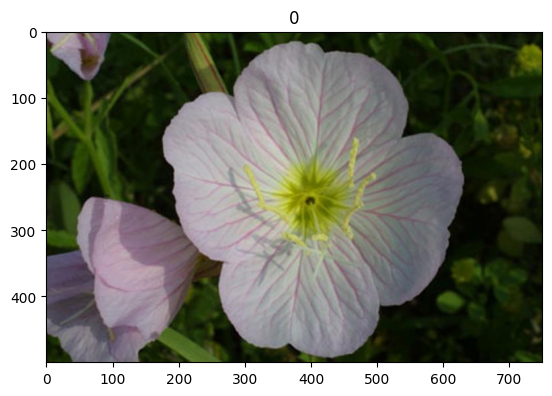

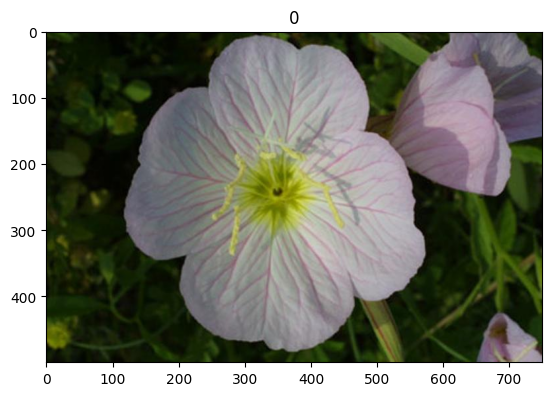

In [ ]:
for i in range(10,20):
  im, lbl=lector[i]
  plt.figure()
  plt.imshow(im)
  plt.title(lbl);